### Importing nessary library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


### data loading

In [3]:
df = pd.read_csv('weather_classification_data.csv')
df.head()


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [4]:
df.sample(10, random_state=11)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
9983,34.0,74,8.5,21.0,partly cloudy,1016.79,2,Winter,7.5,coastal,Cloudy
12160,-8.0,91,6.5,63.0,overcast,984.53,0,Winter,4.5,mountain,Snowy
5420,31.0,67,19.5,86.0,overcast,1005.02,1,Summer,4.0,coastal,Rainy
8622,17.0,71,9.0,81.0,overcast,1009.56,10,Winter,4.5,inland,Cloudy
8435,-5.0,74,14.5,94.0,overcast,991.47,1,Winter,5.0,mountain,Snowy
7891,36.0,61,4.5,10.0,partly cloudy,1018.51,11,Winter,9.5,mountain,Sunny
6320,17.0,78,10.5,71.0,overcast,992.32,2,Winter,3.5,mountain,Rainy
5759,-1.0,88,17.5,99.0,overcast,984.40,0,Winter,3.0,mountain,Snowy
5286,21.0,70,5.5,18.0,partly cloudy,1004.33,4,Autumn,6.0,coastal,Cloudy
10485,12.0,60,11.0,63.0,overcast,1009.03,1,Spring,4.5,coastal,Rainy


In [5]:
df.nunique()

Temperature              126
Humidity                  90
Wind Speed                97
Precipitation (%)        110
Cloud Cover                4
Atmospheric Pressure    5456
UV Index                  15
Season                     4
Visibility (km)           41
Location                   3
Weather Type               4
dtype: int64

In [27]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# col = ['Cloud Cover', 'Season', 'Weather Type']
# for i in col:
#     df[i] = le.fit_transform(df[i])





In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [9]:

# Apply astype(int) only to numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64', 'bool']).columns
df[numeric_columns] = df[numeric_columns].astype(int)

In [ ]:
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Weather Type,Location_inland,Location_mountain
0,14,73,9,82,3,1010,2,3,3,1,1,0
1,39,96,8,71,3,1011,7,1,10,0,1,0
2,30,64,7,16,0,1018,5,1,5,3,0,1
3,38,83,1,82,0,1026,7,1,1,3,0,0
4,27,74,17,66,2,990,1,3,2,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
13195,10,74,14,71,2,1003,1,2,1,1,0,1
13196,-1,76,3,23,1,1067,1,3,6,2,0,0
13197,30,77,5,28,2,1012,3,0,9,0,0,0
13198,3,76,10,94,2,984,0,3,2,2,1,0


In [10]:
df.describe()


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Location_inland,Location_mountain
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.583939,53.644394,1005.333485,4.005758,5.210379,0.364848,0.364621
std,17.386327,20.194248,6.913737,31.946541,37.195745,3.856600,3.380024,0.481406,0.481342
min,-25.000000,20.000000,0.000000,0.000000,800.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.000000,1.000000,3.000000,0.000000,0.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.000000,3.000000,5.000000,0.000000,0.000000
75%,31.000000,84.000000,13.000000,82.000000,1016.000000,7.000000,7.000000,1.000000,1.000000
max,109.000000,109.000000,48.000000,109.000000,1199.000000,14.000000,20.000000,1.000000,1.000000


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Temperature           13200 non-null  int64 
 1   Humidity              13200 non-null  int64 
 2   Wind Speed            13200 non-null  int64 
 3   Precipitation (%)     13200 non-null  int64 
 4   Cloud Cover           13200 non-null  object
 5   Atmospheric Pressure  13200 non-null  int64 
 6   UV Index              13200 non-null  int64 
 7   Season                13200 non-null  object
 8   Visibility (km)       13200 non-null  int64 
 9   Weather Type          13200 non-null  object
 10  Location_inland       13200 non-null  int64 
 11  Location_mountain     13200 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 1.2+ MB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

Temperature             126
Humidity                 90
Wind Speed               49
Precipitation (%)       110
Cloud Cover               4
Atmospheric Pressure    382
UV Index                 15
Season                    4
Visibility (km)          21
Weather Type              4
Location_inland           2
Location_mountain         2
dtype: int64

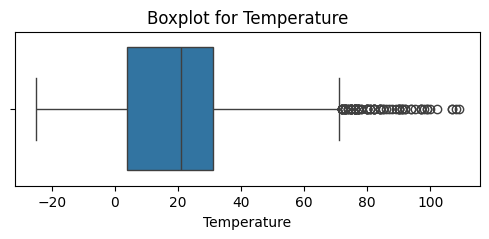

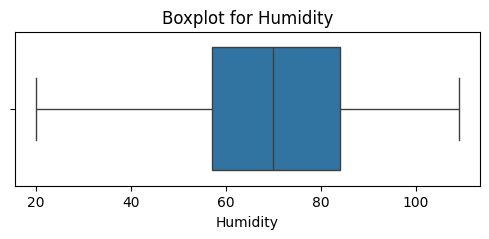

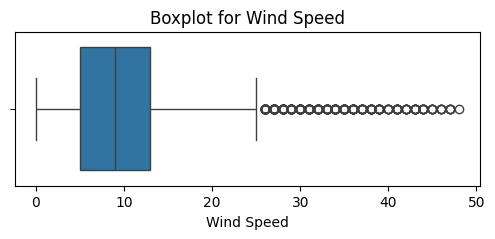

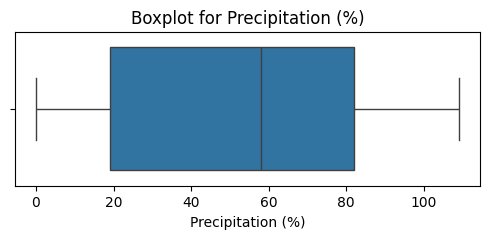

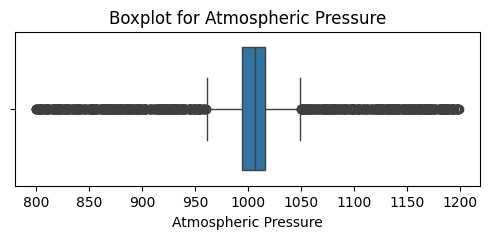

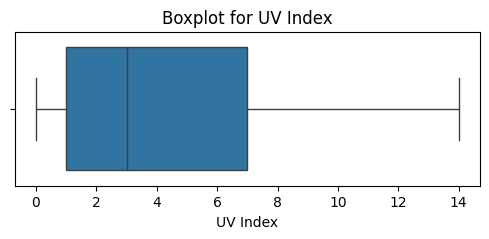

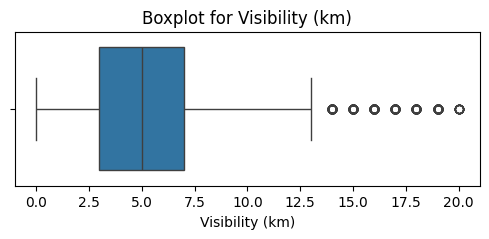

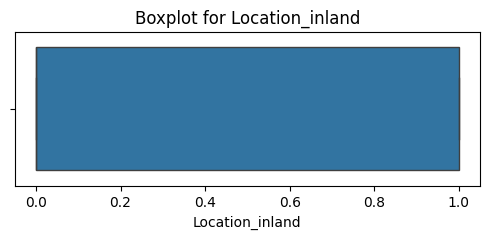

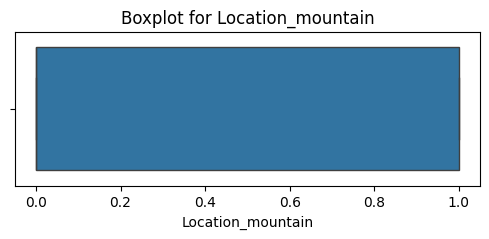

In [14]:
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()

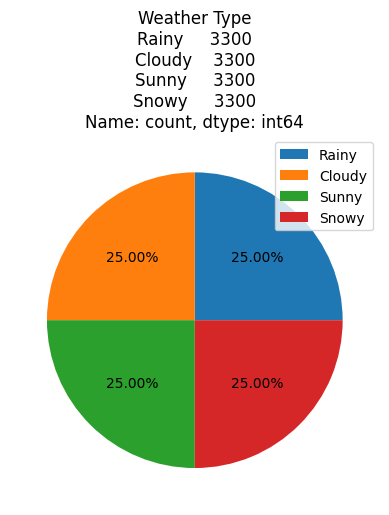

In [15]:
plt.pie(df['Weather Type'].value_counts().values,autopct='%0.02f%%')

plt.legend(df['Weather Type'].unique())

plt.title(f'{df['Weather Type'].value_counts()}')

plt.show()

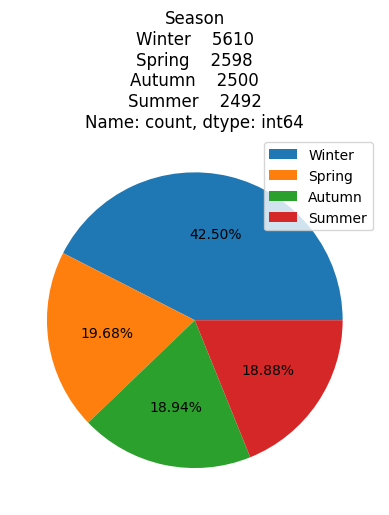

In [17]:
plt.pie(df['Season'].value_counts().values,autopct='%0.02f%%')

plt.legend(['Winter', 'Spring', 'Autumn' ,'Summer'])

plt.title(f'{df['Season'].value_counts()}')

plt.show()

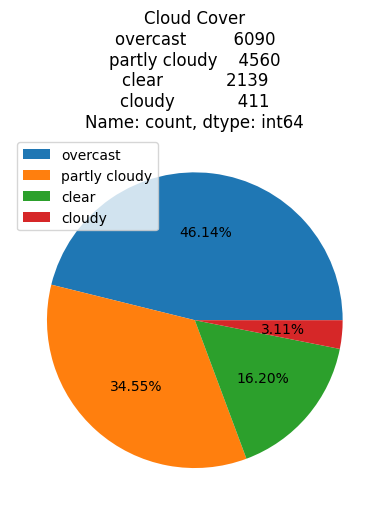

In [18]:
plt.pie(df['Cloud Cover'].value_counts().values,autopct='%0.02f%%')

plt.legend(['overcast','partly cloudy','clear','cloudy'])

plt.title(f'{df['Cloud Cover'].value_counts()}')

plt.show()

In [19]:
X=df.drop(columns='Weather Type')
y=df['Weather Type']

In [20]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.25 , random_state=42)

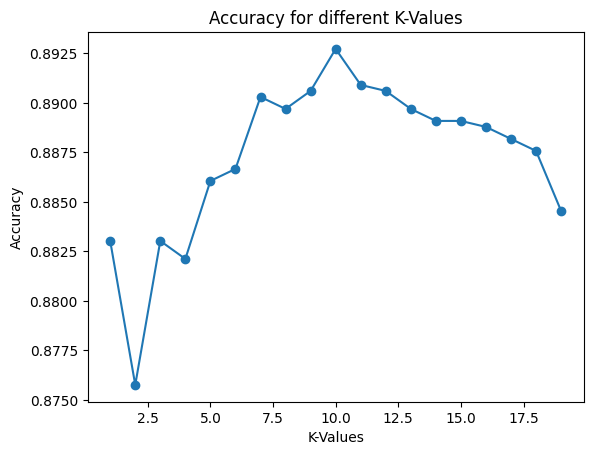

In [23]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
categorical_columns = ['Cloud Cover', 'Season']
le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# Now rerun the KNN training loop
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel('K-Values')
plt.ylabel('Accuracy')
plt.title('Accuracy for different K-Values')
plt.show()

In [24]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train , y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test , y_pred)
print(f"Accuracy of KNN with K=10: {accuracy:.2f}")


Accuracy of KNN with K=10: 0.89


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

      Cloudy       0.85      0.86      0.86       797
       Rainy       0.86      0.90      0.88       822
       Snowy       0.93      0.95      0.94       865
       Sunny       0.93      0.86      0.89       816

    accuracy                           0.89      3300
   macro avg       0.89      0.89      0.89      3300
weighted avg       0.89      0.89      0.89      3300



In [26]:
results = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': y_pred
})

print(results.sample(20))

      Actual Predicted
3141  Cloudy    Cloudy
2414   Snowy     Snowy
787    Snowy     Snowy
2685  Cloudy    Cloudy
2305   Rainy     Rainy
68     Rainy     Rainy
205    Sunny     Sunny
1108  Cloudy    Cloudy
1830  Cloudy    Cloudy
2360   Snowy     Snowy
817    Sunny     Sunny
1075   Sunny     Sunny
2541   Snowy     Snowy
2224  Cloudy    Cloudy
172    Rainy     Rainy
179    Snowy     Snowy
988    Sunny     Sunny
357   Cloudy    Cloudy
1904   Rainy     Rainy
1833  Cloudy    Cloudy


Text(95.72222222222221, 0.5, 'Truh')

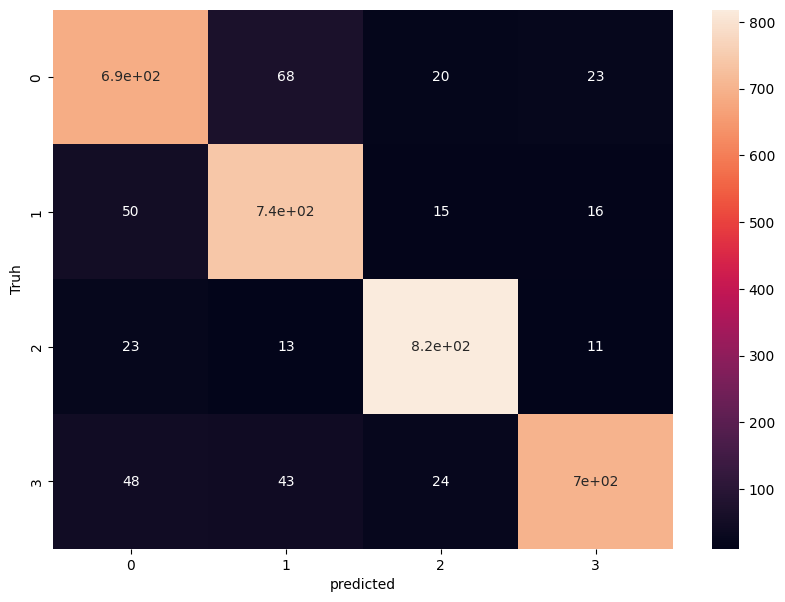

In [27]:
from sklearn.metrics import confusion_matrix
cm1 = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm1,annot=True)
plt.xlabel('predicted')
plt.ylabel('Truh')